In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

sns.set(style="whitegrid")


In [2]:
# Load dataset
df = pd.read_csv("adult_income.csv")

# Clean strings
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

# Encode target
df['income'] = LabelEncoder().fit_transform(df['income'])

# One-hot encode
X = pd.get_dummies(df.drop('income', axis=1))
y = df['income']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [3]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [4]:
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("🔢 Individual Scores:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4942
           1       0.75      0.61      0.67      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.77      0.79      6513
weighted avg       0.85      0.86      0.85      6513

🔢 Individual Scores:
Accuracy: 0.8570551205281745
Precision: 0.7488335925349923
Recall: 0.6129853596435392
F1 Score: 0.6741337066853342
ROC-AUC: 0.9078042401983957


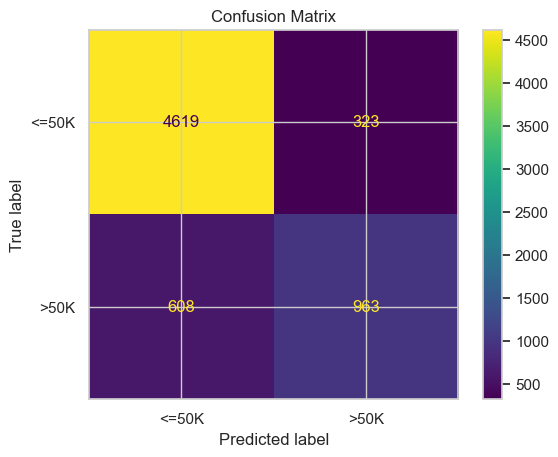

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['<=50K', '>50K'])
plt.title("Confusion Matrix")
plt.show()


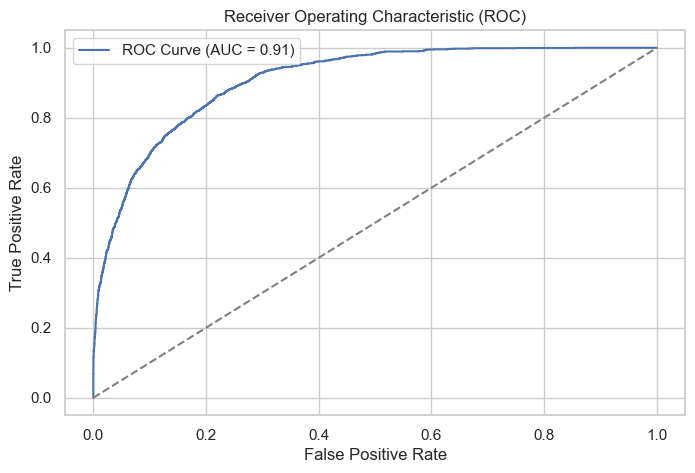

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(roc_auc_score(y_test, y_proba)))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
def weighted_cost_fn(y_true, y_pred, fn_weight=5, fp_weight=1):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cost = fn_weight * fn + fp_weight * fp
    return cost

cost = weighted_cost_fn(y_test, y_pred)
print(f"🔧 Custom Cost (FN weighted 5x more): {cost}")


🔧 Custom Cost (FN weighted 5x more): 3363
